RMSE: 0.04383393724430836
R^2: 0.9741897722281943


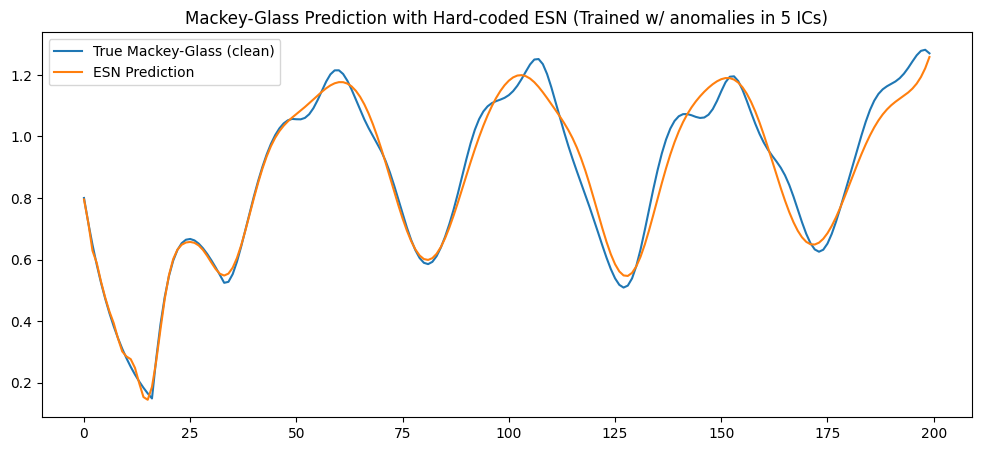

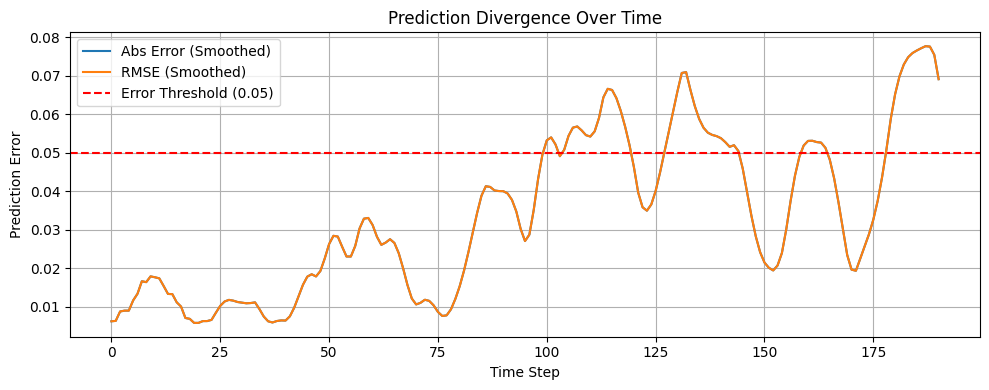

Prediction horizon at threshold 0.05 sustained for 10 steps: 113 steps

F-statistic: 3717.8166
P-value: 1.1102e-16
The model's predictions are statistically significant (p < 0.05).

Total runtime: 32.95 seconds


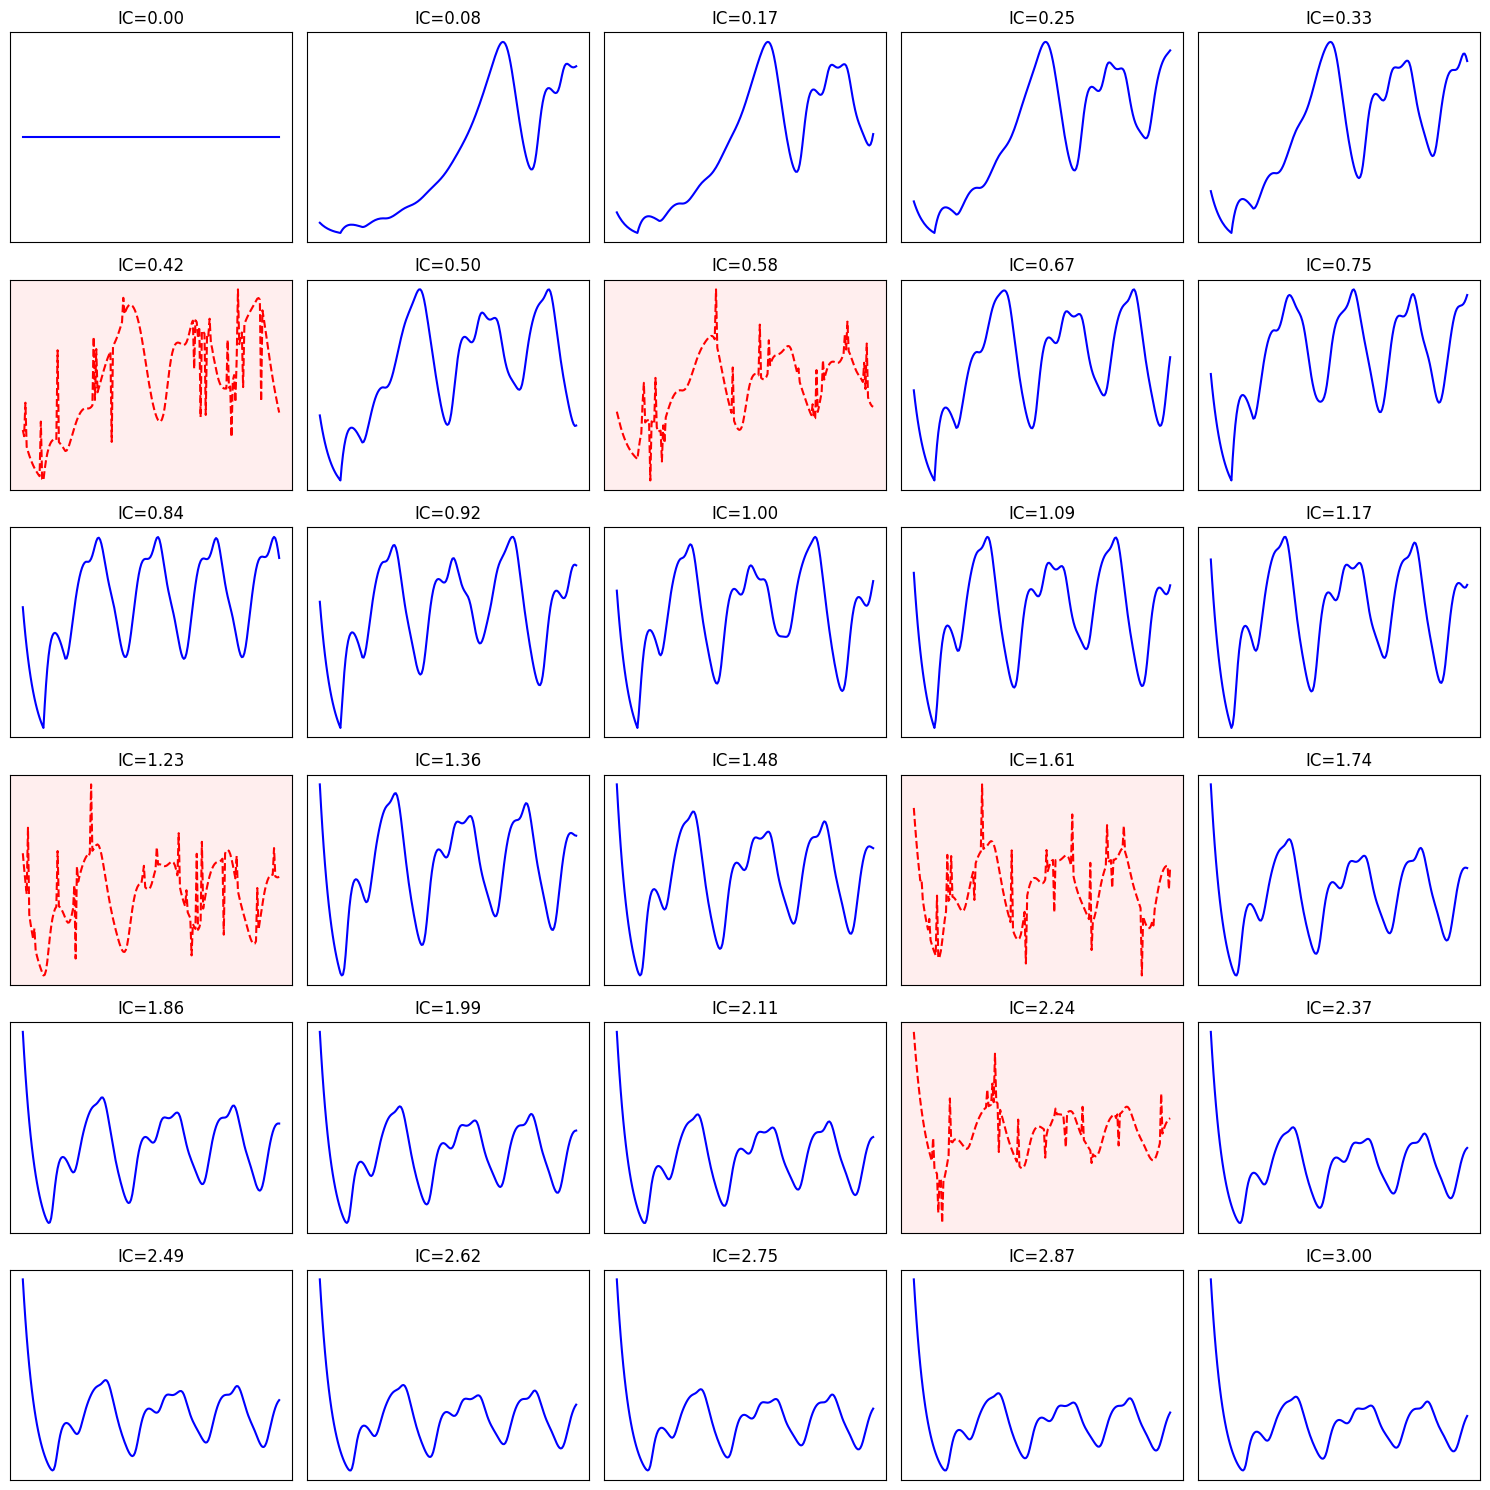

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f
from time import time
import math

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=0.8):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1])
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 0.8
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data (clean) ---
x_test = mackey_glass(t_max=t_max, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test


# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Hard-coded Reservoir ---
start_time = time()
np.random.seed(42)
n_reservoir = 2500
n_input = X_scaled.shape[1]
spectral_radius = 1.0
lr = 0.5  # leak rate

# Input weights
Win = np.random.uniform(-1, 1, (n_reservoir, n_input))
# Reservoir weights
W = np.random.uniform(-1, 1, (n_reservoir, n_reservoir))
# Scale to spectral radius
rho_W = max(abs(np.linalg.eigvals(W)))
W *= spectral_radius / rho_W

# --- Collect reservoir states for training ---
def run_reservoir(X_seq):
    T = X_seq.shape[0]
    states = np.zeros((T, n_reservoir))
    x = np.zeros(n_reservoir)
    for t in range(T):
        u = X_seq[t]
        x = (1 - lr) * x + lr * np.tanh(np.dot(Win, u) + np.dot(W, x))
        states[t] = x
    return states

# Reshape training sequences
n_train = len(train_ics)
X_rnn_states = []
y_rnn_targets = []
for i in range(n_train):
    states = run_reservoir(X_scaled[i*t_max:(i+1)*t_max])
    X_rnn_states.append(states)
    y_rnn_targets.append(y[i*t_max:(i+1)*t_max].reshape(-1, 1))

X_states_train = np.vstack(X_rnn_states)
y_train = np.vstack(y_rnn_targets)

# --- Train readout (Ridge Regression) ---
ridge = Ridge(alpha=1e-7)
ridge.fit(X_states_train, y_train)

# --- Test ---
X_states_test = run_reservoir(X_test_scaled)
y_pred = ridge.predict(X_states_test).flatten()

washout = 0

# --- Error metrics ---
errors = np.abs(y_pred[washout:] - y_test[washout:])
rmse_window = np.sqrt((y_pred[washout:] - y_test[washout:])**2)

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

rmse = np.sqrt(mean_squared_error(y_test[washout:], y_pred[washout:]))
r2 = r2_score(y_test[washout:], y_pred[washout:])
print("RMSE:", rmse)
print("R^2:", r2)

plt.figure(figsize=(12,5))
plt.plot(y_test[washout:], label='True Mackey-Glass (clean)')
plt.plot(y_pred[washout:], label='ESN Prediction')
plt.legend()
plt.title('Mackey-Glass Prediction with Hard-coded ESN (Trained w/ anomalies in 5 ICs)')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)")
plt.plot(smoothed_rmse, label="RMSE (Smoothed)")
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Divergence detection ---
threshold = 0.05
sustain_steps = 10
above_thresh = smoothed_error > threshold
sustained = np.convolve(above_thresh.astype(int), np.ones(sustain_steps, dtype=int), mode='valid') >= sustain_steps
if np.any(sustained):
    divergence_time = np.argmax(sustained) + sustain_steps - 1
    print(f"Prediction horizon at threshold {threshold} sustained for {sustain_steps} steps: {divergence_time} steps")
else:
    print(f"No sustained divergence above threshold {threshold} for {sustain_steps} steps detected.")

# --- F-test ---
n_samples = len(y_test[washout:])
k = X_test_scaled.shape[1]

F = (r2 / k) / ((1 - r2) / (n_samples - k - 1))
p_value = 1 - f.cdf(F, k, n_samples - k - 1)
print(f"\nF-statistic: {F:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("The model's predictions are statistically significant (p < 0.05).")
else:
    print("The model's predictions are NOT statistically significant (p ≥ 0.05).")
end_time = time()
print(f"\nTotal runtime: {end_time - start_time:.2f} seconds")

import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()